In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

In [10]:
df = pd.read_csv(
    "daily_food.csv",
    engine='python',           # uses slower but smarter parser
    on_bad_lines='skip',       # skips the broken line(s) automatically
    encoding='utf-8',
    quotechar='"',             # helps with any quoted fields
)

In [11]:
print("✅ Successfully loaded!")
print(f"Shape: {df.shape} (rows, columns)")
print(f"Columns: {df.columns.tolist()}")
print("\nFirst 5 rows:")
print(df.head())

✅ Successfully loaded!
Shape: (645, 12) (rows, columns)
Columns: [' Food_Item', 'Category', 'Calories (kcal)', 'Protein (g)', 'Carbohydrates (g)', 'Fat (g)', 'Fiber (g)', 'Sugars (g)', 'Sodium (mg)', 'Cholesterol (mg)', 'Meal_Type', 'Water_Intake (ml)']

First 5 rows:
                     Food_Item       Category  Calories (kcal)  Protein (g)  \
0     Scrambled Eggs (2 large)  Protein/Dairy              180         12.0   
1  Whole Wheat Toast (1 slice)          Grain               80          4.0   
2               Coffee (black)       Beverage                5          0.3   
3                       Banana          Fruit              105          1.3   
4        Grilled Chicken Salad   Meal/Protein              350         30.0   

   Carbohydrates (g)  Fat (g)  Fiber (g)  Sugars (g)  Sodium (mg)  \
0                2.0     14.0        0.0         1.0          180   
1               14.0      1.0        2.0         2.0          140   
2                0.0      0.1        0.0         

In [12]:
print(df.isna().sum())

 Food_Item           0
Category             0
Calories (kcal)      0
Protein (g)          0
Carbohydrates (g)    0
Fat (g)              0
Fiber (g)            0
Sugars (g)           0
Sodium (mg)          0
Cholesterol (mg)     0
Meal_Type            0
Water_Intake (ml)    0
dtype: int64


In [13]:
# Unique categories & meal types
print(df['Category'].value_counts())
print(df['Meal_Type'].value_counts())

Category
Condiment               120
Vegetable                70
Grain                    59
Beverage                 54
Fruit                    34
Protein/Meat             31
Meal/Processed           30
Dessert                  27
Dairy                    27
Meal/Meat                20
Meal/Pasta               16
Snack/Processed          16
Nut                      14
Legume                   11
Meal/Vegetarian          10
Protein/Fish              9
Meal/Vegetable            9
Protein/Vegetarian        8
Grain/Processed           8
Meal/Seafood              7
Condiment/Dairy           6
Meal/Protein              5
Protein/Seafood           5
Meal/Grain                5
Meal/Soup                 4
Protein                   4
Vegetable/Processed       3
Beverage/Dairy-Alt        3
Meal/Legume               3
Meal/Fish                 3
Beverage/Dairy            3
Protein/Processed         2
Snack                     2
Beverage/Meal             2
Meal/Rice                 2
Grain/Desse

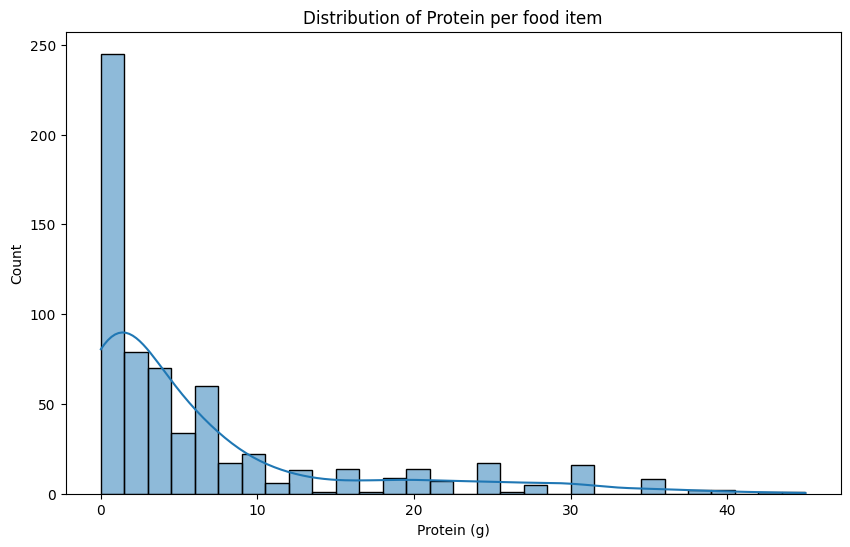

In [14]:
# Distribution of Protein
plt.figure(figsize=(10,6))
sns.histplot(df['Protein (g)'], bins=30, kde=True)
plt.title("Distribution of Protein per food item")
plt.show()

In [16]:
# Diagnostic: Check actual columns and first few rows
print("Actual Columns:")
print(df.columns.tolist())
print("\nFirst 3 Rows (raw):")
print(df.head(3))
print("\nData Types:")
print(df.dtypes)
print("\nAny Dupe/Missing Columns?")
print("Duplicates in columns:", df.columns.duplicated().any())

Actual Columns:
[' Food_Item', 'Category', 'Calories (kcal)', 'Protein (g)', 'Carbohydrates (g)', 'Fat (g)', 'Fiber (g)', 'Sugars (g)', 'Sodium (mg)', 'Cholesterol (mg)', 'Meal_Type', 'Water_Intake (ml)']

First 3 Rows (raw):
                     Food_Item       Category  Calories (kcal)  Protein (g)  \
0     Scrambled Eggs (2 large)  Protein/Dairy              180         12.0   
1  Whole Wheat Toast (1 slice)          Grain               80          4.0   
2               Coffee (black)       Beverage                5          0.3   

   Carbohydrates (g)  Fat (g)  Fiber (g)  Sugars (g)  Sodium (mg)  \
0                2.0     14.0        0.0         1.0          180   
1               14.0      1.0        2.0         2.0          140   
2                0.0      0.1        0.0         0.0            5   

   Cholesterol (mg)  Meal_Type  Water_Intake (ml)  
0               370  Breakfast                250  
1                 0  Breakfast                  0  
2                 0  Bre

In [20]:
required_cols = ['Food_Item', 'Protein (g)', 'Category']
missing_cols = [col for col in required_cols if col not in df.columns]
if missing_cols:
    print(f"⚠️ Missing columns: {missing_cols}. Available: {df.columns.tolist()}")
    # Fallback: Use first 3 columns if exact match fails
    fallback_cols = df.columns[:3].tolist()
    top_protein = df.nlargest(10, 'Protein (g)')[fallback_cols]
else:
    top_protein = df.nlargest(10, 'Protein (g)')[required_cols]

print("\nTop 10 highest protein foods:")
print(top_protein)

⚠️ Missing columns: ['Food_Item']. Available: [' Food_Item', 'Category', 'Calories (kcal)', 'Protein (g)', 'Carbohydrates (g)', 'Fat (g)', 'Fiber (g)', 'Sugars (g)', 'Sodium (mg)', 'Cholesterol (mg)', 'Meal_Type', 'Water_Intake (ml)']

Top 10 highest protein foods:
                        Food_Item        Category  Calories (kcal)
545         Osso Buco (1 serving)       Meal/Meat              550
27       Beef Steak (6oz sirloin)    Protein/Meat              270
243     Veal Parmesan (1 serving)       Meal/Meat              550
337         Chicken Parm Sandwich  Meal/Processed              650
189            T-Bone Steak (6oz)    Protein/Meat              460
555       Saltimbocca (1 serving)       Meal/Meat              380
68   Chicken Breast (4oz roasted)    Protein/Meat              185
118  Chicken Breast (4oz roasted)    Protein/Meat              185
198    Chicken Alfredo (1.5 cups)      Meal/Pasta              680
299                 Club Sandwich  Meal/Processed              5

In [ ]:

import pandas as pd  # Ensure imported

# Auto-Fix Columns: Strip spaces & standardize names
df.columns = df.columns.str.strip()  # Remove leading/trailing spaces
# Common fix: Replace space with underscore if needed
if 'Food Item' in df.columns:
    df.rename(columns={'Food Item': 'Food_Item'}, inplace=True)
print("🔧 Columns fixed. Actual now:", df.columns.tolist()[:5])  # Preview first 5

# Safe Unique Foods Count
food_col = 'Food_Item'  # Target name
if food_col not in df.columns:
    # Fallback: Use first column (likely food names) or guess
    food_col = df.columns[0]  # Assumes first col is foods
    print(f"⚠️ Using fallback column: '{food_col}' (original '{food_col}' missing)")

unique_foods = df[food_col].nunique()

# Total Columns
total_cols = df.shape[1]

# Thresholds (Proposal: ≥600 foods, ≥12 cols)
min_foods, min_cols = 600, 12

# Status Prints (Your Original Logic)
print(f"✅ Unique Foods: {unique_foods} (>= {min_foods}) → {'PASSED' if unique_foods >= min_foods else 'FAILED'}")
print(f"✅ Columns: {total_cols} (>= {min_cols}) → {'PASSED' if total_cols >= min_cols else 'FAILED'}")

# Overall Check
criteria_met = unique_foods >= min_foods and total_cols >= min_cols
print(f"\n🎉 Objective 1: {'SUCCESS' if criteria_met else 'PARTIAL'}")

# Bonus: If PARTIAL, suggest next steps
if not criteria_met:
    print("\n💡 Fix Tips:")
    if unique_foods < min_foods:
        print("   - Add more rows to CSV (aim for 1000+ total for 600 uniques).")
    if total_cols < min_cols:
        print("   - Check CSV headers: Ensure 12+ cols like 'Protein (g)', 'Fiber (g)'. Re-save file.")

🔧 Columns fixed. Actual now: ['Food_Item', 'Category', 'Calories (kcal)', 'Protein (g)', 'Carbohydrates (g)']
✅ Unique Foods: 587 (>= 600) → FAILED
✅ Columns: 12 (>= 12) → PASSED

🎉 Objective 1: PARTIAL

💡 Fix Tips:
   - Add more rows to CSV (aim for 1000+ total for 600 uniques).


In [23]:
# Key X Features (Proposal: Calories, Protein, etc. for deficiency prediction)
key_features = ['Calories (kcal)', 'Protein (g)', 'Carbohydrates (g)', 'Fat (g)', 
                'Fiber (g)', 'Sugars (g)', 'Sodium (mg)', 'Cholesterol (mg)']

missing = [f for f in key_features if f not in df.columns]
print(f"Key Features: {key_features}")
print(f"Missing: {missing if missing else 'None'}")

if not missing:
    print(df[key_features].describe().round(2))

Key Features: ['Calories (kcal)', 'Protein (g)', 'Carbohydrates (g)', 'Fat (g)', 'Fiber (g)', 'Sugars (g)', 'Sodium (mg)', 'Cholesterol (mg)']
Missing: None
       Calories (kcal)  Protein (g)  Carbohydrates (g)  Fat (g)  Fiber (g)  \
count           645.00       645.00             645.00   645.00     645.00   
mean            146.29         6.30              15.44     6.47       1.70   
std             139.98         8.78              16.35     8.14       2.12   
min               0.00         0.00               0.00     0.00       0.00   
25%              42.00         0.50               1.30     0.20       0.00   
50%             105.00         2.70               9.20     3.00       1.00   
75%             200.00         7.00              27.00    10.00       3.00   
max             680.00        45.00              70.00    40.00      14.00   

       Sugars (g)  Sodium (mg)  Cholesterol (mg)  
count      645.00       645.00            645.00  
mean         5.29       246.33        

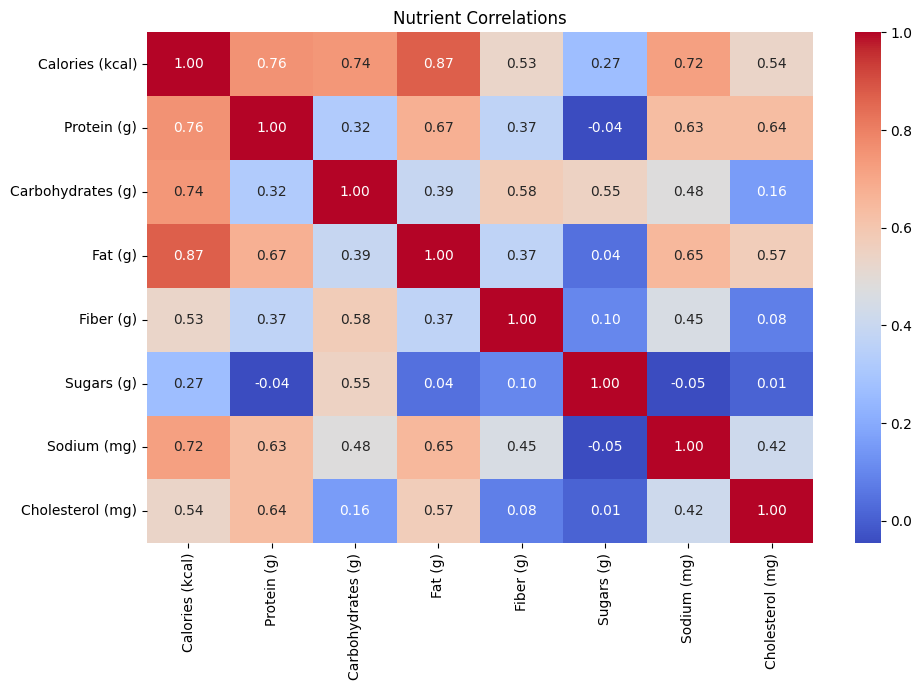

In [24]:
# Nutrient Correlations (for feature selection in PCA)
plt.figure(figsize=(10, 7))
corr = df[key_features].corr()
sns.heatmap(corr, annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Nutrient Correlations')
plt.tight_layout()
plt.show()

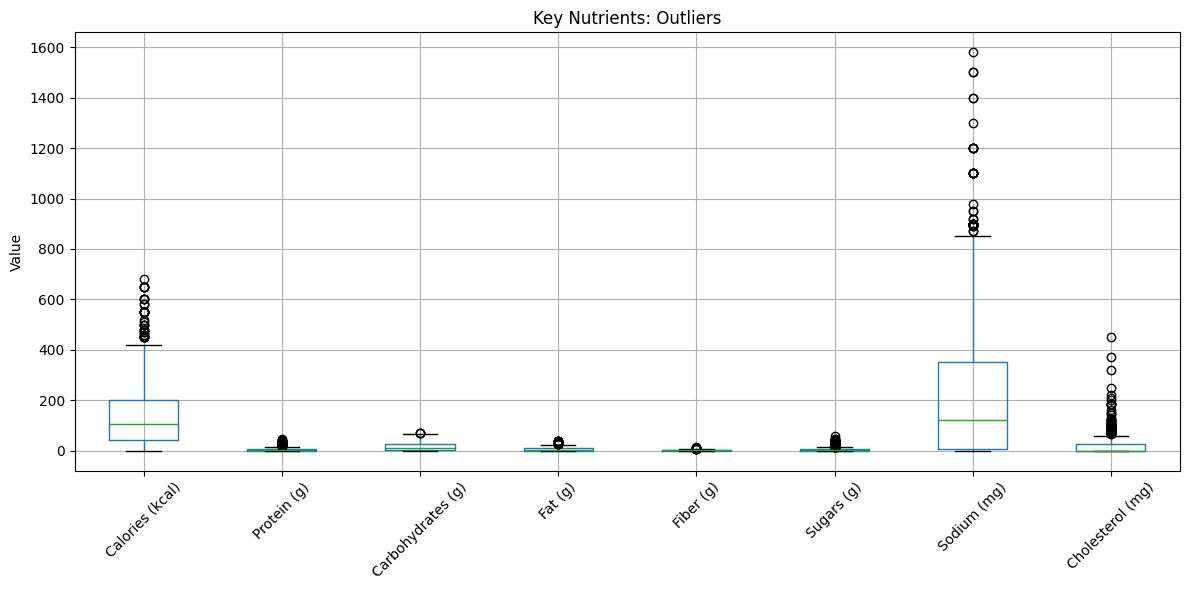

In [25]:
# Boxplots for Outliers (Prep for cleaning in Objective 2)
plt.figure(figsize=(12, 6))
df[key_features].boxplot(rot=45)
plt.title('Key Nutrients: Outliers')
plt.ylabel('Value')
plt.tight_layout()
plt.show()

In [26]:
# Top 10 Foods (Focus: Protein, Fiber, Sodium per proposal)
tops = {
    'Calories': df.nlargest(10, 'Calories (kcal)')[['Food_Item', 'Calories (kcal)', 'Category']],
    'Fiber': df.nlargest(10, 'Fiber (g)')[['Food_Item', 'Fiber (g)', 'Category']],
    'Sodium': df.nlargest(10, 'Sodium (mg)')[['Food_Item', 'Sodium (mg)', 'Category']]
}

for nutrient, table in tops.items():
    print(f"\nTop 10 {nutrient}:")
    display(table)


Top 10 Calories:


,Food_Item,Calories (kcal),Category
198,Chicken Alfredo (1.5 cups),680,Meal/Pasta
218,Reuben Sandwich,650,Meal/Processed
308,Beef Burrito (large),650,Meal/Processed
337,Chicken Parm Sandwich,650,Meal/Processed
505,Carbonara (1.5 cups),650,Meal/Pasta
253,Eggs Benedict (1 serving),600,Meal/Protein
328,Gyro (1 sandwich),600,Meal/Meat
440,Beef Wellington (1 slice),600,Meal/Meat
156,Meatball Sub (6 inch),580,Meal/Processed
299,Club Sandwich,580,Meal/Processed



Top 10 Fiber:


,Food_Item,Fiber (g),Category
534,Ribollita (1.5 cups soup),14.0,Meal/Soup
19,Lentil Soup (1 can),12.0,Meal/Legume
259,Hummus Wrap (large),12.0,Meal/Vegetarian
31,Avocado Toast (1 slice),10.0,Meal/Vegetarian
292,Split Pea Soup (1 cup),10.0,Meal/Legume
308,Beef Burrito (large),10.0,Meal/Processed
399,Acai Bowl (1 serving),10.0,Meal/Fruit
620,Lentil Soup (1 cup Middle Eastern),10.0,Meal/Legume
301,Turkey Chili (1 cup),8.0,Meal/Meat
323,Raspberries (1 cup),8.0,Fruit



Top 10 Sodium:


,Food_Item,Sodium (mg),Category
193,Ramen (Instant 1 pack),1580,Meal/Processed
218,Reuben Sandwich,1500,Meal/Processed
410,Beef Pho (1 large bowl),1500,Meal/Soup
308,Beef Burrito (large),1400,Meal/Processed
337,Chicken Parm Sandwich,1400,Meal/Processed
299,Club Sandwich,1300,Meal/Processed
156,Meatball Sub (6 inch),1200,Meal/Processed
300,Pickle (1 whole dill),1200,Vegetable
328,Gyro (1 sandwich),1200,Meal/Meat
431,Kimchi Jjigae (1 bowl),1200,Meal/Soup


In [27]:
# Avg Nutrition by Meal Type (For pattern analysis/clustering)
meal_avg = df.groupby('Meal_Type')[key_features].mean().round(2)
print("Avg per Meal Type:")
display(meal_avg)

Avg per Meal Type:


,Calories (kcal),Protein (g),Carbohydrates (g),Fat (g),Fiber (g),Sugars (g),Sodium (mg),Cholesterol (mg)
Meal_Type,,,,,,,,
Breakfast,135.62,4.12,17.58,5.68,1.44,6.73,193.38,23.22
Dinner,162.34,8.68,14.67,7.59,1.88,2.39,288.82,28.50
Lunch,163.24,8.31,14.91,7.81,2.08,3.08,382.86,19.22
Side,22.00,1.70,4.00,0.40,2.40,1.50,750.00,0.00
Snack,118.54,2.82,15.78,4.41,1.31,10.01,105.47,10.27


In [28]:
# Save for Report (Proposal: Dataset collection summary)
summary = {
    'objective': 1,
    'unique_foods': unique_foods,
    'shape': list(df.shape),
    'key_features': key_features,
    'criteria_met': criteria_met
}

import json
with open('obj1_summary.json', 'w') as f:
    json.dump(summary, f, indent=2)

df.to_csv('nutri_data_clean.csv', index=False)
print("\n💾 Saved: obj1_summary.json & nutri_data_clean.csv")


💾 Saved: obj1_summary.json & nutri_data_clean.csv
